# Lab 4 · The Fashion VAE — a Latent Playground + Impostor Detector
**MSACL · DS301 Deep Learning · Segment 4 · Lab 4**

In Lecture 11 you met the **autoencoder** — a network that squeezes a picture through a narrow
**bottleneck** and rebuilds it — and its smoother cousin the **variational autoencoder (VAE)**,
which learns an *organized* latent space you can plot, walk through, and sample from.

This lab makes those ideas playful. You will build a VAE that **only knows clothes**
(FashionMNIST — shirts, sneakers, bags, boots). Then you'll:

- **plot its 2-D latent map** and see clothing types cluster (VAE vs. a plain autoencoder),
- **morph** one garment smoothly into another by walking the latent space,
- **generate brand-new clothes** by decoding random latent points, and
- turn it into an **impostor detector**: show your clothes-VAE some **handwritten digits**
  (MNIST) and it botches them → **high reconstruction error** → caught as impostors.

The whole thing trains in about **20 seconds** and downloads its data for free (no logins).

**You fill in four short pieces**, all ideas that matter:
1. **The VAE loss** — combine the two terms that define a VAE (Blank 1).
2. **KL by hand** — compute one tiny KL value with a calculator (Blank 2).
3. **The impostor threshold** — the sensitivity/specificity dial (Blank 3, + a prediction).
4. **Draw your own impostor** — an ASCII doodle the VAE will judge (Blank 4).

Everything else — the model, the training loop, and every plot — runs as-is.
This is a ~45-minute session (+ 10 min discussion).

## ⚙️ Setup — run this cell first

Run the next cell **before anything else**. On Colab it installs the course's
packages and downloads the data for this lab, checking every file's fingerprint;
on your own computer it uses the files already in the course folder. It takes
about a minute the first time. You do not need to read or edit it.

In [ ]:
# ── MSACL DS301 · SETUP — run this cell first; no need to read or edit it ──
import sys, subprocess, urllib.request, pathlib
if "google.colab" in sys.modules:          # on Colab: fetch the course helper
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "uv"], check=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/indigobio/msacl_dl_course/main/student_pack/msacl.py",
        "msacl.py")
else:                                        # locally: use the course folder's copy
    here = pathlib.Path.cwd()
    helper = next(p for d in (here, *here.parents)
                  for p in (d / "msacl.py", d / "student_pack" / "msacl.py") if p.exists())
    sys.path.insert(0, str(helper.parent))
import msacl
DATA = msacl.setup("lab04")                  # {file name: where it is on this machine}

## Step 0 · Setup — load the clothes (and the impostors) *(runs for you)*

The setup cell above already downloaded two classic image datasets for you:

- **NORMAL = FashionMNIST** — 28×28 grayscale clothing. Our VAE trains only on these.
- **IMPOSTORS = MNIST** — 28×28 handwritten digits. The VAE has *never* seen these; later
  they'll be the "unfamiliar" inputs our detector must flag.

Both are already scaled to `[0, 1]` and flattened to a 784-length vector (28×28) for the MLP.

Libraries ready. Device: mps
train clothes (12000, 784) | held-out clothes (2000, 784) | impostor digits (2000, 784)


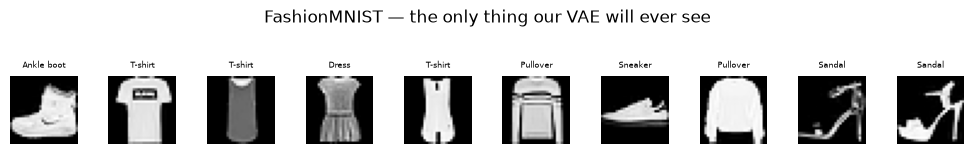

In [1]:
# Read and run — no need to edit.
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

def seed_everything(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)

seed_everything(0)

# Use a GPU (Colab T4) if present, else Apple MPS, else CPU. This tiny model is fast anywhere.
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

# NORMAL = clothing (FashionMNIST); IMPOSTORS = handwritten digits (MNIST).
# The setup cell fetched all three image sets in one file (raw 0-255 pixels).
images = np.load(DATA["fashion_mnist_vae.npz"])

FASHION_CLASSES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                   "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def load_flat(name):
    """Images as a flat (n, 784) tensor in [0, 1], plus integer labels."""
    pixels = torch.from_numpy(images[name + "_x"]).float()
    X = pixels.view(len(pixels), -1) / 255.0
    y = images[name + "_y"].astype(np.int64)
    return X.to(DEVICE), y

X_train, y_train = load_flat("fashion_train")       # 12,000 clothes the VAE learns from
X_normal, y_normal = load_flat("fashion_test")      # 2,000 held-out clothes ("normal" test)
X_impostor, _ = load_flat("mnist_test")             # 2,000 digits the VAE has never seen

print(f"Libraries ready. Device: {DEVICE}")
print(f"train clothes {tuple(X_train.shape)} | held-out clothes {tuple(X_normal.shape)} "
      f"| impostor digits {tuple(X_impostor.shape)}")

# Fun visual #1: a row of the clothes our VAE will learn.
fig, axes = plt.subplots(1, 10, figsize=(10, 1.3))
for j in range(10):
    axes[j].imshow(X_train[j].cpu().view(28, 28), cmap="Greys_r", vmin=0, vmax=1)
    axes[j].set_title(FASHION_CLASSES[y_train[j]], fontsize=6)
    axes[j].axis("off")
fig.suptitle("FashionMNIST — the only thing our VAE will ever see", y=1.15)
plt.tight_layout(); plt.show()

## Step 1 · Build the VAE *(runs for you)*

Here is the whole model — the same shape as Lecture 11's picture:

- **Encoder:** `784 → 256 → 64`, then split into two 2-D vectors: **`mu`** (the center of a
  latent cloud) and **`logvar`** (how spread out the cloud is).
- **Reparameterize:** draw one sample `z = mu + eps · exp(½·logvar)` from that cloud — the
  trick that lets us train through the randomness.
- **Decoder:** `2 → 64 → 256 → 784`, ending in a sigmoid so pixels land back in `[0, 1]`.

We use a **2-D latent** on purpose: small enough to force real compression, and exactly 2 so
we can *plot* the whole latent space on a flat page.

In [2]:
# Read and run — no need to edit.
INPUT_DIM = 784           # 28 x 28 pixels, flattened
LATENT_DIM = 2            # a 2-D latent so we can plot the whole map
H1, H2 = 256, 64          # two hidden widths on the way down (and back up)

class FashionVAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        # encoder: 784 -> 256 -> 64, then split into mu and logvar
        self.enc = nn.Sequential(nn.Linear(INPUT_DIM, H1), nn.ReLU(),
                                 nn.Linear(H1, H2), nn.ReLU())
        self.fc_mu     = nn.Linear(H2, latent_dim)
        self.fc_logvar = nn.Linear(H2, latent_dim)
        # decoder: latent -> 64 -> 256 -> 784, sigmoid back into 0..1
        self.dec = nn.Sequential(nn.Linear(latent_dim, H2), nn.ReLU(),
                                 nn.Linear(H2, H1), nn.ReLU(),
                                 nn.Linear(H1, INPUT_DIM), nn.Sigmoid())

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)      # sigma = exp(1/2 * logvar)
        eps = torch.randn_like(std)        # random noise, one draw per image
        return mu + eps * std              # a sample from the latent cloud

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# quick shape probe (structure only)
_probe = FashionVAE().to(DEVICE)
_recon, _mu, _logvar = _probe(X_train[:4])
assert _recon.shape == (4, INPUT_DIM), f"decoder must return (4, 784); got {tuple(_recon.shape)}"
assert _mu.shape == (4, LATENT_DIM), f"mu must be (4, {LATENT_DIM}); got {tuple(_mu.shape)}"
print("VAE built. recon:", tuple(_recon.shape), "| mu:", tuple(_mu.shape))

VAE built. recon: (4, 784) | mu: (4, 2)


## Step 2 · The VAE loss — YOUR TURN ✏️ (Blank 1)

A VAE is trained on **two ideas at once**:

1. **Reconstruction** — rebuild the input well. We score this with the squared pixel error,
   summed over the 784 pixels and averaged over the batch. (Provided as `recon_loss`.)
2. **Keep the latent tidy (KL)** — pull every latent cloud gently toward the origin so the
   space stays smooth and sampleable. The formula is

   $$\mathrm{KL} = -\tfrac{1}{2}\sum_i \big(1 + \text{logvar}_i - \text{mu}_i^2 - e^{\text{logvar}_i}\big)$$

   (Provided as `kl_loss`.)

**Your one line:** combine them into the total `loss`, with the KL term weighted by `BETA`
(set to `1.0` for you). A VAE needs *both* — reconstruction alone would just be a plain
autoencoder, and a wrong sign would push the latent apart instead of tidying it.

In [3]:
BETA = 1.0        # weight on the KL "tidiness" term (provided)

def vae_loss(recon, x, mu, logvar, beta):
    # 1. reconstruction: per-image squared error, averaged over the batch (provided)
    recon_loss = ((recon - x) ** 2).sum(dim=1).mean()
    # 2. KL "tidiness": push each latent cloud toward the origin (provided)
    kl_loss = (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1)).mean()

    # ---- Blank 1: combine the two terms, KL weighted by beta ----
    ### BEGIN SOLUTION
    loss = recon_loss + beta * kl_loss
    ### END SOLUTION

    return loss, recon_loss, kl_loss

# --- self-checks: do not edit ---
_recon, _mu, _logvar = _probe(X_train[:8])
_loss, _rl, _kl = vae_loss(_recon, X_train[:8], _mu, _logvar, BETA)
assert _loss.dim() == 0 and torch.isfinite(_loss), "loss must be a single finite number (a scalar)"
assert _kl.item() >= -1e-6, "the KL term is a distance and can never be negative"
assert abs(_loss.item() - (_rl.item() + BETA * _kl.item())) < 1e-4, \
    "loss must equal recon_loss + BETA * kl_loss (not recon alone, and not a minus sign)"
print(f"loss = {_loss.item():.3f}  =  recon {_rl.item():.3f}  +  BETA*KL {BETA * _kl.item():.3f}")

loss = 135.590  =  recon 135.585  +  BETA*KL 0.005


## Step 3 · KL by hand — YOUR TURN ✏️ (Blank 2)

Let's make that KL formula concrete with a calculator — no code, just the numbers. Take **one**
latent cloud with

$$\text{mu} = [1,\, 0], \qquad \text{logvar} = [0,\, 0].$$

Plug into $\mathrm{KL} = -\tfrac{1}{2}\sum_i \big(1 + \text{logvar}_i - \text{mu}_i^2 - e^{\text{logvar}_i}\big)$,
remembering $e^{0} = 1$:

- dimension 1: $1 + 0 - 1^2 - e^{0} = 1 + 0 - 1 - 1 = -1$
- dimension 2: $1 + 0 - 0^2 - e^{0} = 1 + 0 - 0 - 1 = 0$
- sum $= -1$, so $\mathrm{KL} = -\tfrac{1}{2}(-1)$.

**Set `kl_by_hand` to that final number.** (This is Quiz-style — do it on paper, then let the
code confirm it computes the same thing on the same numbers.)

In [4]:
# ---- Blank 2: the KL value you computed by hand for mu=[1,0], logvar=[0,0] ----
### BEGIN SOLUTION
kl_by_hand = 0.5
### END SOLUTION

# --- self-check: do not edit ---
# the code evaluates the SAME KL formula on the SAME numbers; your answer must match it.
_mu_ex     = torch.tensor([[1.0, 0.0]])
_logvar_ex = torch.tensor([[0.0, 0.0]])
kl_from_code = (-0.5 * (1 + _logvar_ex - _mu_ex.pow(2) - _logvar_ex.exp()).sum(dim=1)).item()
assert abs(kl_by_hand - kl_from_code) < 1e-6, \
    f"recompute by hand: the formula gives {kl_from_code}, but kl_by_hand = {kl_by_hand}"
print(f"KL by hand = {kl_by_hand}  matches the code's {kl_from_code}  ✓")

KL by hand = 0.5  matches the code's 0.5  ✓


## Step 4 · Train the VAE on clothes *(runs for you)*

A short loop: Adam, learning rate `1e-3`, batch 128, ~12 passes over 12,000 clothes. Uses
**your loss** from Step 2. About 20 seconds — watch the loss fall.

  epoch  0   loss   65.88
  epoch  1   loss   37.82
  epoch  2   loss   34.93
  epoch  3   loss   33.87
  epoch  4   loss   33.17
  epoch  5   loss   32.44
  epoch  6   loss   32.00
  epoch  7   loss   31.57
  epoch  8   loss   31.25
  epoch  9   loss   30.94
  epoch 10   loss   30.70
  epoch 11   loss   30.45
Training done: 12 epochs in 3 s.


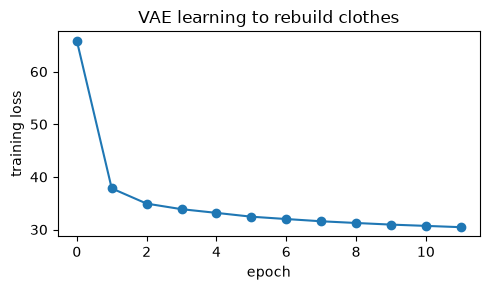

In [5]:
# Read and run — no need to edit.
seed_everything(0)
vae = FashionVAE().to(DEVICE)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
EPOCHS, BATCH = 12, 128

vae.train()
loss_history = []
t0 = time.time()
for epoch in range(EPOCHS):
    order = torch.randperm(len(X_train), device=DEVICE)
    epoch_loss = 0.0
    for start in range(0, len(X_train), BATCH):
        xb = X_train[order[start:start + BATCH]]
        recon, mu, logvar = vae(xb)
        loss, _, _ = vae_loss(recon, xb, mu, logvar, BETA)   # <-- your objective from Step 2
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(X_train)
    loss_history.append(epoch_loss)
    print(f"  epoch {epoch:2d}   loss {epoch_loss:7.2f}")
print(f"Training done: {EPOCHS} epochs in {time.time() - t0:.0f} s.")

plt.figure(figsize=(5, 3))
plt.plot(range(EPOCHS), loss_history, marker="o")
plt.xlabel("epoch"); plt.ylabel("training loss"); plt.title("VAE learning to rebuild clothes")
plt.tight_layout(); plt.show()

## Step 5 · The latent playground — VAE vs. plain autoencoder *(fun visual #2)*

Now the Lecture 11 headline picture. We encode every held-out garment to its 2-D latent center
`mu` and scatter it, colored by clothing type. Beside it we train a **plain autoencoder** — same
shape, but with **no KL term** — and plot *its* latent.

Watch the difference: the **VAE**'s codes sit in a tidy blob around the origin with types blending
smoothly (great for sampling and morphing); the **plain AE** spreads codes into scattered islands
with gaps that decode to garbage.

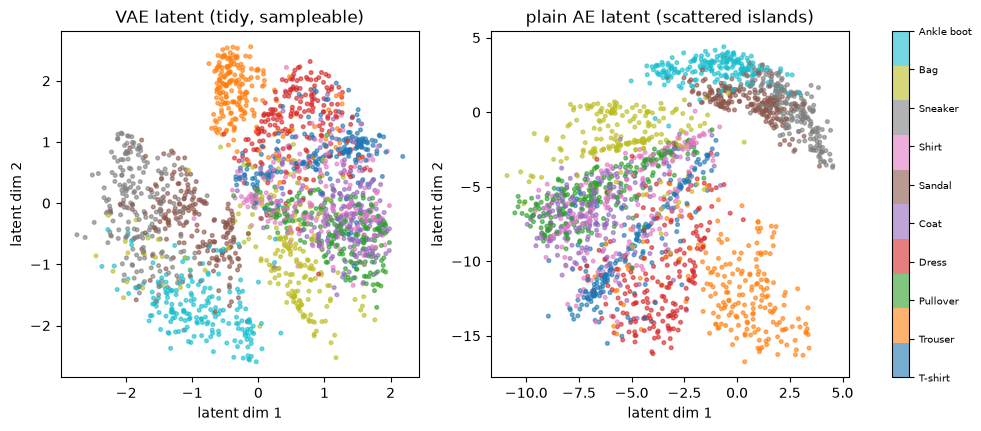

In [6]:
# Read and run — no need to edit.  A plain autoencoder: same shape, but NO KL term.
class PlainAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(INPUT_DIM, H1), nn.ReLU(),
                                 nn.Linear(H1, H2), nn.ReLU(), nn.Linear(H2, latent_dim))
        self.dec = nn.Sequential(nn.Linear(latent_dim, H2), nn.ReLU(),
                                 nn.Linear(H2, H1), nn.ReLU(),
                                 nn.Linear(H1, INPUT_DIM), nn.Sigmoid())
    def forward(self, x):
        z = self.enc(x)
        return self.dec(z), z

seed_everything(0)
ae = PlainAE().to(DEVICE)
ae_opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
ae.train()
for epoch in range(12):
    order = torch.randperm(len(X_train), device=DEVICE)
    for start in range(0, len(X_train), BATCH):
        xb = X_train[order[start:start + BATCH]]
        recon, _ = ae(xb)
        loss = ((recon - xb) ** 2).sum(dim=1).mean()   # reconstruction ONLY (no KL)
        ae_opt.zero_grad(); loss.backward(); ae_opt.step()

# grab both latent maps (deterministic: use mu / the AE code, no sampling)
vae.eval(); ae.eval()
with torch.no_grad():
    vae_latent = vae.encode(X_normal)[0].cpu().numpy()
    ae_latent = ae(X_normal)[1].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, latent, title in [(axes[0], vae_latent, "VAE latent (tidy, sampleable)"),
                          (axes[1], ae_latent, "plain AE latent (scattered islands)")]:
    sc = ax.scatter(latent[:, 0], latent[:, 1], c=y_normal, cmap="tab10", s=7, alpha=0.6)
    ax.set_title(title); ax.set_xlabel("latent dim 1"); ax.set_ylabel("latent dim 2")
cb = fig.colorbar(sc, ax=axes, ticks=range(10), fraction=0.025)
cb.ax.set_yticklabels(FASHION_CLASSES, fontsize=7)
plt.show()

## Step 6 · Morph one garment into another *(fun visual #3)*

Because the VAE's latent is smooth, a **straight line between two codes decodes to a smooth
morph**. We take a **sneaker** and an **ankle boot**, encode each to its latent center, then
decode 8 points along the line between them. Watch the shoe grow a heel.

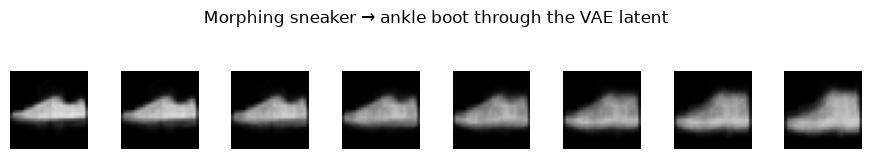

In [7]:
# Read and run — no need to edit.
i_sneaker = int(np.where(y_normal == 7)[0][0])   # class 7 = Sneaker
i_boot    = int(np.where(y_normal == 9)[0][0])   # class 9 = Ankle boot

vae.eval()
with torch.no_grad():
    z_a = vae.encode(X_normal[i_sneaker:i_sneaker + 1])[0]
    z_b = vae.encode(X_normal[i_boot:i_boot + 1])[0]
    alphas = torch.linspace(0, 1, 8, device=DEVICE).unsqueeze(1)
    morph = vae.decode((1 - alphas) * z_a + alphas * z_b).view(-1, 28, 28).cpu().numpy()

fig, axes = plt.subplots(1, 8, figsize=(9, 1.4))
for j in range(8):
    axes[j].imshow(morph[j], cmap="Greys_r", vmin=0, vmax=1); axes[j].axis("off")
fig.suptitle("Morphing sneaker → ankle boot through the VAE latent", y=1.1)
plt.tight_layout(); plt.show()

## Step 7 · Generate brand-new clothes *(fun visual #4)*

Because the VAE tidied its latent toward the origin, we can **sample the prior** — draw random
points `z ~ N(0, I)` — and decode them into **clothes that never existed**. No input image, pure
generation. (A plain autoencoder can't do this: sample its scattered latent and you mostly hit
gaps that decode to noise.)

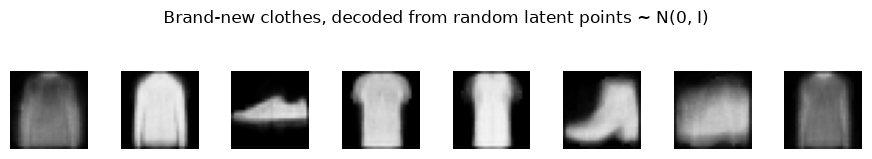

In [8]:
# Read and run — no need to edit.
seed_everything(1)
with torch.no_grad():
    z_samples = torch.randn(8, LATENT_DIM, device=DEVICE)     # random points from the prior N(0, I)
    generated = vae.decode(z_samples).view(-1, 28, 28).cpu().numpy()

fig, axes = plt.subplots(1, 8, figsize=(9, 1.4))
for j in range(8):
    axes[j].imshow(generated[j], cmap="Greys_r", vmin=0, vmax=1); axes[j].axis("off")
fig.suptitle("Brand-new clothes, decoded from random latent points ~ N(0, I)", y=1.1)
plt.tight_layout(); plt.show()

## Step 8 · The impostor detector — YOUR TURN ✏️ (Blank 3 + a prediction)

Now the payoff. An autoencoder rebuilds **familiar** things well and **unfamiliar** things badly.
So **reconstruction error** is our impostor score: we compute it on held-out **clothes**
(`normal_errors`) and on **digits** (`impostor_errors`) the VAE has never seen.

You set the **threshold** — the sensitivity/specificity dial from Lecture 10. The rule: **put the
line at the 90th percentile of the *normal* errors**, so we accept about a **10% false-alarm rate**
on real clothes while catching as many impostor digits as we can above it.

$$\texttt{THRESHOLD} = \texttt{np.percentile(normal\_errors, 90)}$$

Then **predict**, before looking: if 10% of normal clothes fall above a 90th-percentile line, how
many of the `len(normal_errors)` normal images should raise a false alarm? Fill `expected_false_alarms`.

In [9]:
# reconstruction error = per-image mean squared error, scored deterministically from mu
def recon_error(model, X):
    model.eval()
    with torch.no_grad():
        mu, _ = model.encode(X)
        recon = model.decode(mu)                 # use the mean (no random sampling) for scoring
    return ((recon - X) ** 2).mean(dim=1).cpu().numpy()

normal_errors   = recon_error(vae, X_normal)     # held-out CLOTHES  (should rebuild well -> low)
impostor_errors = recon_error(vae, X_impostor)   # DIGITS            (unfamiliar     -> high)

# ---- Blank 3: the threshold = the 90th percentile of the NORMAL errors ----
### BEGIN SOLUTION
THRESHOLD = np.percentile(normal_errors, 90)
### END SOLUTION

# ---- Blank 3 (predict): how many of the normal images should be false alarms at the 90th pct? ----
### BEGIN SOLUTION
expected_false_alarms = round(0.10 * len(normal_errors))
### END SOLUTION

# --- self-checks: do not edit ---
assert np.isfinite(THRESHOLD), "THRESHOLD must be a finite number"
assert normal_errors.min() <= THRESHOLD < normal_errors.max(), \
    "a percentile threshold must land inside the range of the normal errors (not 0, not the max)"
actual_false_alarms = int((normal_errors > THRESHOLD).sum())
assert abs(expected_false_alarms - actual_false_alarms) <= 20, \
    f"a 90th-pct line flags ~10% of normal images; you predicted {expected_false_alarms}, " \
    f"actual {actual_false_alarms}"

false_alarm_rate = (normal_errors > THRESHOLD).mean()
catch_rate       = (impostor_errors > THRESHOLD).mean()
print(f"THRESHOLD (90th pct of normal): {THRESHOLD:.4f}")
print(f"false-alarm rate on clothes : {false_alarm_rate:.0%}  "
      f"(predicted {expected_false_alarms} / actual {actual_false_alarms} of {len(normal_errors)})")
print(f"impostor catch rate on digits: {catch_rate:.0%}")

THRESHOLD (90th pct of normal): 0.0573
false-alarm rate on clothes : 10%  (predicted 200 / actual 200 of 2000)
impostor catch rate on digits: 74%


### Does it really work? A distribution-level check *(runs for you)*

One threshold is a single operating point. **AUROC** summarizes *every* threshold at once: the
chance a random impostor scores higher than a random normal. `0.5` is coin-flip; `1.0` is perfect.
We also show the funniest evidence — the digits the clothes-VAE mangled the most.

In [ ]:
# Read and run — no need to edit.
def rank_auroc(pos, neg):
    """AUROC via rank sum (Mann-Whitney): P(a random pos scores above a random neg)."""
    both = np.concatenate([pos, neg])
    order = both.argsort()
    ranks = np.empty(len(both)); ranks[order] = np.arange(1, len(both) + 1)
    return (ranks[:len(pos)].sum() - len(pos) * (len(pos) + 1) / 2) / (len(pos) * len(neg))

auroc = rank_auroc(impostor_errors, normal_errors)
print(f"mean error  — clothes (normal): {normal_errors.mean():.4f}   digits (impostor): {impostor_errors.mean():.4f}")
print(f"AUROC (clothes vs. digits): {auroc:.3f}")

assert impostor_errors.mean() > normal_errors.mean(), \
    "impostor digits should be rebuilt worse (higher error) on average than clothes"
assert auroc > 0.85, f"the detector should separate digits from clothes well (AUROC {auroc:.3f} should be > 0.85)"

# the 8 digits the clothes-VAE botched the most (top: real digit, bottom: VAE's clothes-brained guess)
vae.eval()
with torch.no_grad():
    recon_imp = vae.decode(vae.encode(X_impostor)[0]).view(-1, 28, 28).cpu().numpy()
worst = np.argsort(-impostor_errors)[:8]
orig_imp = X_impostor.view(-1, 28, 28).cpu().numpy()

fig, axes = plt.subplots(2, 8, figsize=(9, 2.4))
for j, k in enumerate(worst):
    axes[0, j].imshow(orig_imp[k], cmap="Greys_r", vmin=0, vmax=1); axes[0, j].axis("off")
    axes[1, j].imshow(recon_imp[k], cmap="Greys_r", vmin=0, vmax=1); axes[1, j].axis("off")
axes[0, 0].set_title("impostor digit (input)", loc="left", fontsize=8)
axes[1, 0].set_title("clothes-VAE's botched rebuild", loc="left", fontsize=8)
plt.tight_layout(); plt.show()

## Step 9 · Draw your own impostor — YOUR TURN ✏️ (Blank 4)

Your turn to fool — or get caught by — the detector. Edit the 16×16 ASCII grid below: `'#'` is
ink, `'.'` is blank. It ships with a **thin spiral** (which flags reliably). Try your initials, a
squiggle, or a molecule sketch. The code upsamples it to 28×28, scores its reconstruction error,
and tells you whether it lands **above** the threshold (flagged as an impostor) or slips through.

> **Teachable nuance:** thin lines and text score high (very unlike a solid garment) and flag
> easily; a big solid blob looks more clothes-like and may sneak under the line.

In [11]:
# ---- Blank 4: draw YOUR impostor below. '#' = ink, '.' = blank. Keep every row 16 chars. ----
# A thin spiral ships as the default (it flags). Replace it with your own doodle and re-run.
DOODLE = [
    "................",
    "....########....",
    "...#........#...",
    "..#..######..#..",
    "..#.#......#.#..",
    "..#.#.####.#.#..",
    "..#.#.#..#.#.#..",
    "..#.#.#..#.#.#..",
    "..#.#.####.#.#..",
    "..#.#......#.#..",
    "..#..######..#..",
    "...#........#...",
    "....########....",
    "................",
    "................",
    "................",
]
### BEGIN SOLUTION
DOODLE = [
    "................",
    "....########....",
    "...#........#...",
    "..#..######..#..",
    "..#.#......#.#..",
    "..#.#.####.#.#..",
    "..#.#.#..#.#.#..",
    "..#.#.#..#.#.#..",
    "..#.#.####.#.#..",
    "..#.#......#.#..",
    "..#..######..#..",
    "...#........#...",
    "....########....",
    "................",
    "................",
    "................",
]
### END SOLUTION

Run this cell to turn your grid into a 28×28 image, score it, and see where it lands.
*(runs for you)*

your doodle's reconstruction error: 0.0861   (threshold 0.0573)
its latent position: (+0.48, -0.32)
VERDICT: FLAGGED as an impostor ⚑


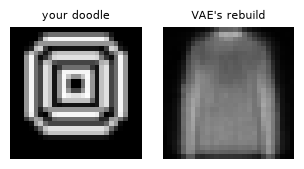

In [12]:
# Read and run — no need to edit.
# --- sanity check on YOUR grid: catch a mis-typed doodle early, with a clear message ---
assert isinstance(DOODLE, list) and len(DOODLE) == 16, "DOODLE must be a list of 16 rows"
row_lengths = {len(r) for r in DOODLE}
assert row_lengths == {16}, f"every row of DOODLE must be exactly 16 chars — got lengths {sorted(row_lengths)}"
assert set("".join(DOODLE)) <= {"#", "."}, "use only '#' (ink) and '.' (blank) in your grid"

def doodle_to_image(rows):
    grid = np.array([[1.0 if ch == "#" else 0.0 for ch in r] for r in rows], dtype=np.float32)
    t = torch.from_numpy(grid)[None, None]                       # (1, 1, 16, 16)
    up = F.interpolate(t, size=(28, 28), mode="bilinear", align_corners=False)
    return up.clamp(0, 1).view(1, -1).to(DEVICE)                 # (1, 784) in [0, 1]

doodle_img = doodle_to_image(DOODLE)
assert doodle_img.shape == (1, 784), f"doodle should upsample to (1, 784); got {tuple(doodle_img.shape)}"

doodle_error = float(recon_error(vae, doodle_img)[0])
assert np.isfinite(doodle_error), "the doodle's reconstruction error must be a finite number"

vae.eval()
with torch.no_grad():
    doodle_mu = vae.encode(doodle_img)[0].cpu().numpy()[0]
    doodle_recon = vae.decode(vae.encode(doodle_img)[0]).view(28, 28).cpu().numpy()

flagged = doodle_error > THRESHOLD
print(f"your doodle's reconstruction error: {doodle_error:.4f}   (threshold {THRESHOLD:.4f})")
print(f"its latent position: ({doodle_mu[0]:+.2f}, {doodle_mu[1]:+.2f})")
print("VERDICT:", "FLAGGED as an impostor ⚑" if flagged else "slipped through (looks clothes-like)")

fig, axes = plt.subplots(1, 2, figsize=(3.2, 1.7))
axes[0].imshow(doodle_img.cpu().view(28, 28), cmap="Greys_r", vmin=0, vmax=1)
axes[0].set_title("your doodle", fontsize=8); axes[0].axis("off")
axes[1].imshow(doodle_recon, cmap="Greys_r", vmin=0, vmax=1)
axes[1].set_title("VAE's rebuild", fontsize=8); axes[1].axis("off")
plt.tight_layout(); plt.show()

## Discussion D4

You just built a detector the honest way: **train on "normal," then flag the unfamiliar** by how
badly it rebuilds. Your clothes-VAE never learned digits, so digits reconstruct poorly and get
caught — and *you* chose the threshold that trades false alarms against catches.

**Be honest about the limits.** Reconstruction-error detection catches **gross novelty** (a whole
different kind of input), not **subtle** differences within the normal family — two very similar
things will both rebuild well. That's why this is a QC / novelty tool, not a fine-grained classifier.

**Talk it over:** *Where in YOUR work could "train on normal, flag the unfamiliar" help* — a new
contaminant, an instrument drifting, an out-of-family sample? *And what would a false alarm cost
you* — a re-run, a delayed result, a technician's afternoon? Where would you set the dial?